In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense , Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD ,  Adam
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [3]:
data = pd.read_csv(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Data\Images110.csv')

In [12]:
data.head()

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p36290,p36291,p36292,p36293,p36294,p36295,p36296,p36297,p36298,p36299
0,0,232,240,223,232,240,223,231,239,222,...,130,86,107,134,89,110,137,94,115,142
1,0,225,250,254,229,248,254,229,248,255,...,199,162,191,200,159,190,199,159,190,199
2,0,165,154,122,173,152,120,172,150,122,...,109,23,88,126,21,90,127,19,90,130
3,0,197,197,173,198,202,176,199,201,178,...,78,5,82,85,3,78,80,3,85,86
4,0,218,219,181,235,224,176,228,214,178,...,208,147,204,220,138,195,210,143,203,218


In [13]:
Y_raw = data.iloc[:, 0].values
X_flat = data.iloc[:, 1:].values.astype('float32')


In [14]:
expected = 110 * 110 * 3
if X_flat.shape[1] != expected:
    raise ValueError(f"Expected {expected} columns for image pixels, found {X_flat.shape[1]}")

X = X_flat / 255.0  # normalize to [0,1]


In [15]:
# encode labels and convert to one-hot
le = LabelEncoder()
Y_enc = le.fit_transform(Y_raw)
n_classes = len(np.unique(Y_enc))
Y = to_categorical(Y_enc, n_classes)


In [16]:
# train/test split (stratify to keep class balance)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=30, stratify=Y_enc)

# ANN MODEL 

In [22]:
ANN_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dropout(0.2),

    Dense(n_classes, activation='softmax')
])

opt =Adam(learning_rate=1e-4)
ANN_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
summary = ANN_model.fit(X_train, Y_train, epochs=50, verbose=1)
result = ANN_model.evaluate(X_train, Y_train)
ANN_model.save(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\ANN_model.keras')

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 222ms/step - accuracy: 0.5690 - loss: 1.2365
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - accuracy: 0.7996 - loss: 0.5206
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.8499 - loss: 0.4211
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - accuracy: 0.8384 - loss: 0.4301
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - accuracy: 0.8827 - loss: 0.3257
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.9048 - loss: 0.2778
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - accuracy: 0.9008 - loss: 0.2871
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - accuracy: 0.8973 - loss: 0.2668
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.9290 - loss: 0.2255
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.9345 - loss: 0.1968
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.9396 - loss: 0.1794
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13

In [23]:

print('Loss of train dataset = ', result[0])
print('Accuracy of train dataset = ', result[1])


Loss of train dataset =  0.010963710024952888
Accuracy of train dataset =  0.9984894394874573


In [24]:

result = ANN_model.evaluate(X_test, Y_test)
print('Loss of test dataset = ', result[0])
print('Accuracy of test dataset = ', result[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9477 - loss: 0.1787
Loss of test dataset =  0.17865154147148132
Accuracy of test dataset =  0.9476861357688904


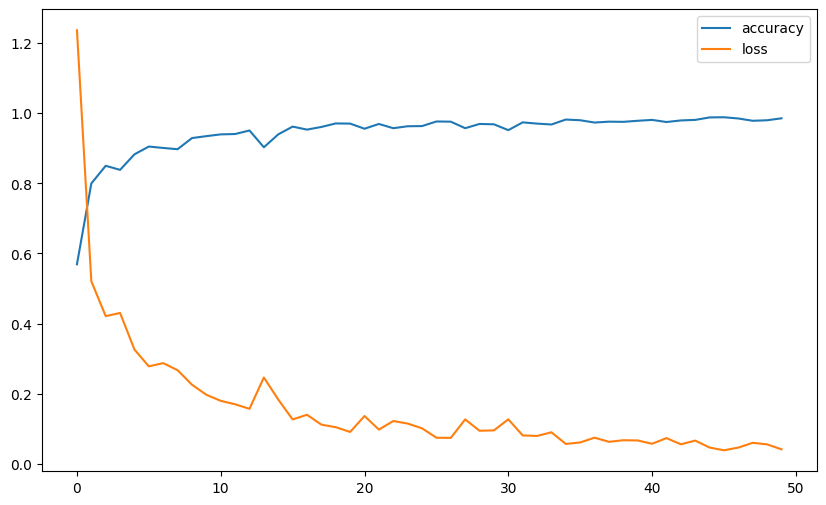

In [25]:
pd.DataFrame(summary.history).plot(figsize=(10, 6))
plt.show()